# VFI CBA Explorer
## Canterbury Rural Nitrate Survey — Study-level Cost-Benefit Analysis

**Framework:** Julian King Value for Investment (VFI) 2017–2024  
**Economic method:** NZ Treasury CBAx  
**QALY benchmark:** ~$45,000 / QALY (NZ)  
**Evaluation level:** Study (single discrete research activity)  

---

This notebook walks through a full CBA for a rural nitrate household survey.  
Two benefit streams are modelled:
- **Stream 1** — Acute infant methaemoglobinaemia risk averted
- **Stream 2** — Chronic adult colorectal cancer (CRC) risk reduction

Run each cell in order. Adjust parameters in **Cell 2** to explore different scenarios.

## Cell 1 — Install and import libraries

In [1]:
import micropip
await micropip.install('matplotlib')
await micropip.install('numpy')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f8'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['font.size']        = 11

print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Set parameters

Adjust any value here and re-run all cells to update the full analysis.

In [2]:
# ── Study parameters ──────────────────────────────────────────
STUDY_COST       = 76_000    # Total study cost ($NZD)
HH_SURVEYED      = 320       # Households surveyed
HH_NOTIFIED      = 90        # Households notified (above nitrate standard)
UPTAKE_RATE      = 0.52      # Proportion taking protective action (base case)

# ── Economic parameters ───────────────────────────────────────
QALY_VALUE       = 45_000    # $/QALY (NZ benchmark)
DISCOUNT_RATE    = 0.06      # 6% — NZ Treasury CBAx default
TIME_HORIZON     = 10        # Years

# ── Benefit stream 1: Acute infant methaemoglobinaemia ────────
INFANT_RATE      = 0.06      # Proportion of notified HH with infant <6 months
P_METH_AVERTED   = 0.15      # Probability of case averted per at-risk infant HH
METH_QALY_LOSS   = 0.08      # QALY loss per methaemoglobinaemia episode

# ── Benefit stream 2: Chronic adult colorectal cancer ─────────
ADULTS_PER_HH    = 1.8       # Average adults per household
CRC_PROB_10YR    = 0.008     # 10-year CRC probability in exposed adults
RR_REDUCTION     = 0.04      # Relative risk reduction from nitrate exposure removal
CRC_QALY_LOSS    = 1.2       # QALY loss per CRC case

print('Parameters set.')
print(f'  Study cost:      ${STUDY_COST:,.0f}')
print(f'  Households:      {HH_SURVEYED} surveyed / {HH_NOTIFIED} notified')
print(f'  Uptake rate:     {UPTAKE_RATE:.0%}')
print(f'  QALY value:      ${QALY_VALUE:,.0f}')
print(f'  Discount rate:   {DISCOUNT_RATE:.0%}')
print(f'  Time horizon:    {TIME_HORIZON} years')

Parameters set.
  Study cost:      $76,000
  Households:      320 surveyed / 90 notified
  Uptake rate:     52%
  QALY value:      $45,000
  Discount rate:   6%
  Time horizon:    10 years


## Cell 3 — Calculate benefit streams and NPV

In [3]:
def run_cba(uptake=UPTAKE_RATE, cost=STUDY_COST, qaly=QALY_VALUE,
            disc=DISCOUNT_RATE, years=TIME_HORIZON):
    """Run full CBA and return results dict."""
    hh_act = HH_NOTIFIED * uptake

    # Stream 1 — annual
    s1_annual = hh_act * INFANT_RATE * P_METH_AVERTED * METH_QALY_LOSS * qaly

    # Stream 2 — annual (spread evenly across horizon)
    s2_annual = (hh_act * ADULTS_PER_HH * CRC_PROB_10YR *
                 RR_REDUCTION * CRC_QALY_LOSS * qaly) / years

    # Discount year by year
    year_range = np.arange(1, years + 1)
    discount_factors = 1 / (1 + disc) ** year_range
    s1_discounted = s1_annual * discount_factors
    s2_discounted = s2_annual * discount_factors
    total_discounted = s1_discounted + s2_discounted

    pv_benefits = total_discounted.sum()
    npv = pv_benefits - cost
    bcr = pv_benefits / cost

    return {
        'pv_benefits':    pv_benefits,
        'npv':            npv,
        'bcr':            bcr,
        's1_annual':      s1_annual,
        's2_annual':      s2_annual,
        's1_discounted':  s1_discounted,
        's2_discounted':  s2_discounted,
        'year_range':     year_range,
        'discount_factors': discount_factors
    }

def vfi_standard(bcr):
    if bcr >= 3:   return 'Excellent', '#1baf7a'
    if bcr >= 1.5: return 'Good',      '#2a78d6'
    if bcr >= 1.0: return 'Adequate',  '#eda100'
    return             'Poor',      '#e34948'

r = run_cba()
std, col = vfi_standard(r['bcr'])

print('── Base-case results ──────────────────────────────────')
print(f'  Households taking action: {HH_NOTIFIED * UPTAKE_RATE:.0f}')
print(f'  Stream 1 annual benefit:  ${r["s1_annual"]:,.0f}')
print(f'  Stream 2 annual benefit:  ${r["s2_annual"]:,.0f}')
print(f'  PV of total benefits:     ${r["pv_benefits"]:,.0f}')
print(f'  Net present value (NPV):  ${r["npv"]:,.0f}')
print(f'  Benefit-cost ratio (BCR): {r["bcr"]:.2f}')
print(f'  VFI standard:             {std}')

── Base-case results ──────────────────────────────────
  Households taking action: 47
  Stream 1 annual benefit:  $1,516
  Stream 2 annual benefit:  $146
  PV of total benefits:     $12,232
  Net present value (NPV):  $-63,768
  Benefit-cost ratio (BCR): 0.16
  VFI standard:             Poor


## Cell 4 — Plot annual discounted benefit streams

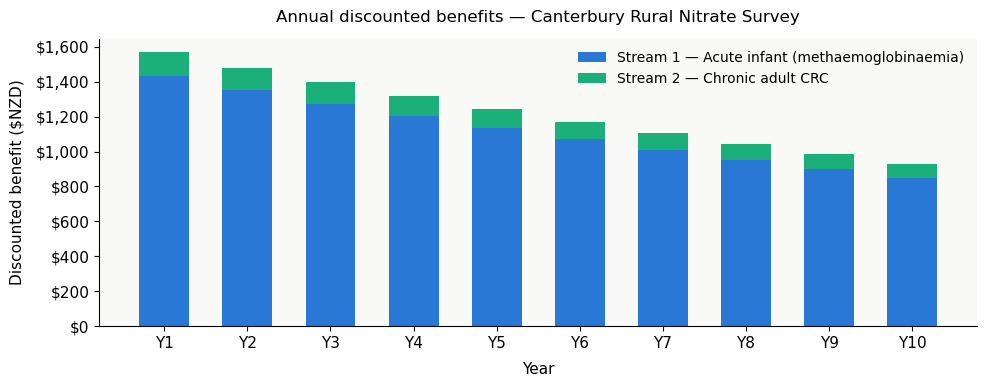

Total PV benefits: $12,232 | Study cost: $76,000


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

bars1 = ax.bar(r['year_range'], r['s1_discounted'],
               color='#2a78d6', label='Stream 1 — Acute infant (methaemoglobinaemia)',
               width=0.6)
bars2 = ax.bar(r['year_range'], r['s2_discounted'],
               bottom=r['s1_discounted'],
               color='#1baf7a', label='Stream 2 — Chronic adult CRC',
               width=0.6)

ax.set_xlabel('Year', labelpad=8)
ax.set_ylabel('Discounted benefit ($NZD)', labelpad=8)
ax.set_title('Annual discounted benefits — Canterbury Rural Nitrate Survey',
             fontsize=12, fontweight='normal', pad=12)
ax.set_xticks(r['year_range'])
ax.set_xticklabels([f'Y{y}' for y in r['year_range']])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(frameon=False, fontsize=10)
ax.axhline(0, color='#c3c2b7', linewidth=0.5)

plt.tight_layout()
plt.show()
print(f'Total PV benefits: ${r["pv_benefits"]:,.0f} | Study cost: ${STUDY_COST:,.0f}')

## Cell 5 — Sensitivity analysis (scenario comparison)

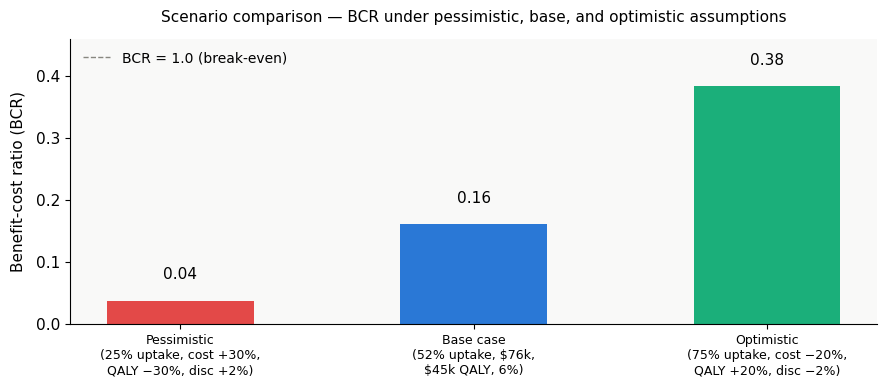

Scenario BCRs:
  Poor        BCR = 0.04  NPV = $-95,047
  Poor        BCR = 0.16  NPV = $-63,768
  Poor        BCR = 0.38  NPV = $-37,470


In [5]:
scenarios = {
    'Pessimistic\n(25% uptake, cost +30%,\nQALY −30%, disc +2%)': run_cba(
        uptake=0.25, cost=STUDY_COST*1.3, qaly=QALY_VALUE*0.7, disc=DISCOUNT_RATE+0.02),
    'Base case\n(52% uptake, $76k,\n$45k QALY, 6%)': run_cba(),
    'Optimistic\n(75% uptake, cost −20%,\nQALY +20%, disc −2%)': run_cba(
        uptake=0.75, cost=STUDY_COST*0.8, qaly=QALY_VALUE*1.2, disc=max(0.02, DISCOUNT_RATE-0.02))
}

labels = list(scenarios.keys())
bcrs   = [v['bcr'] for v in scenarios.values()]
colors = ['#e34948', '#2a78d6', '#1baf7a']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(labels)), bcrs, color=colors, width=0.5)
ax.axhline(1.0, color='#888780', linewidth=1, linestyle='--', label='BCR = 1.0 (break-even)')

for bar, bcr in zip(bars, bcrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{bcr:.2f}', ha='center', va='bottom', fontsize=11, fontweight='500')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Benefit-cost ratio (BCR)', labelpad=8)
ax.set_title('Scenario comparison — BCR under pessimistic, base, and optimistic assumptions',
             fontsize=11, fontweight='normal', pad=12)
ax.legend(frameon=False, fontsize=10)
ax.set_ylim(0, max(bcrs) * 1.2)

plt.tight_layout()
plt.show()

print('Scenario BCRs:')
for name, res in scenarios.items():
    std, _ = vfi_standard(res['bcr'])
    print(f'  {std:10s}  BCR = {res["bcr"]:.2f}  NPV = ${res["npv"]:,.0f}')

## Cell 6 — Tornado chart (parameter sensitivity)

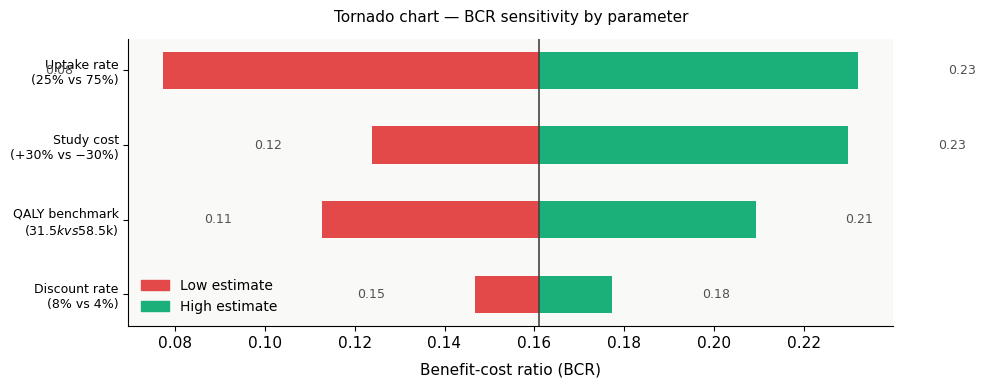

Parameters ranked by influence on BCR (largest range = most influential):
  Uptake rate           range: 0.08 – 0.23  (25% vs 75%)
  Study cost            range: 0.12 – 0.23  (+30% vs −30%)
  QALY benchmark        range: 0.11 – 0.21  ($31.5k vs $58.5k)
  Discount rate         range: 0.15 – 0.18  (8% vs 4%)


In [6]:
base_bcr = run_cba()['bcr']

parameters = [
    ('Uptake rate',
     run_cba(uptake=0.25)['bcr'],
     run_cba(uptake=0.75)['bcr'],
     '25% vs 75%'),
    ('QALY benchmark',
     run_cba(qaly=QALY_VALUE*0.7)['bcr'],
     run_cba(qaly=QALY_VALUE*1.3)['bcr'],
     '$31.5k vs $58.5k'),
    ('Discount rate',
     run_cba(disc=DISCOUNT_RATE+0.02)['bcr'],
     run_cba(disc=max(0.02, DISCOUNT_RATE-0.02))['bcr'],
     '8% vs 4%'),
    ('Study cost',
     run_cba(cost=STUDY_COST*1.3)['bcr'],
     run_cba(cost=STUDY_COST*0.7)['bcr'],
     '+30% vs −30%'),
]

params  = [p[0] for p in parameters]
lows    = [p[1] for p in parameters]
highs   = [p[2] for p in parameters]
notes   = [p[3] for p in parameters]

sorted_idx = sorted(range(len(params)), key=lambda i: highs[i] - lows[i])
params  = [params[i]  for i in sorted_idx]
lows    = [lows[i]    for i in sorted_idx]
highs   = [highs[i]   for i in sorted_idx]
notes   = [notes[i]   for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = range(len(params))

for i, (lo, hi) in enumerate(zip(lows, highs)):
    ax.barh(i, lo - base_bcr, left=base_bcr, color='#e34948', height=0.5)
    ax.barh(i, hi - base_bcr, left=base_bcr, color='#1baf7a', height=0.5)
    ax.text(lo - 0.02, i, f'{lo:.2f}', va='center', ha='right',  fontsize=9, color='#52514e')
    ax.text(hi + 0.02, i, f'{hi:.2f}', va='center', ha='left',   fontsize=9, color='#52514e')

ax.axvline(base_bcr, color='#444441', linewidth=1.2, linestyle='-', label=f'Base BCR = {base_bcr:.2f}')
ax.set_yticks(list(y_pos))
ax.set_yticklabels([f'{p}\n({n})' for p, n in zip(params, notes)], fontsize=9)
ax.set_xlabel('Benefit-cost ratio (BCR)', labelpad=8)
ax.set_title('Tornado chart — BCR sensitivity by parameter',
             fontsize=11, fontweight='normal', pad=12)

lo_patch = mpatches.Patch(color='#e34948', label='Low estimate')
hi_patch = mpatches.Patch(color='#1baf7a', label='High estimate')
ax.legend(handles=[lo_patch, hi_patch], frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

print('Parameters ranked by influence on BCR (largest range = most influential):')
for p, lo, hi, n in zip(reversed(params), reversed(lows), reversed(highs), reversed(notes)):
    print(f'  {p:20s}  range: {lo:.2f} – {hi:.2f}  ({n})')

## Cell 7 — VFI rubric summary (Five Es)

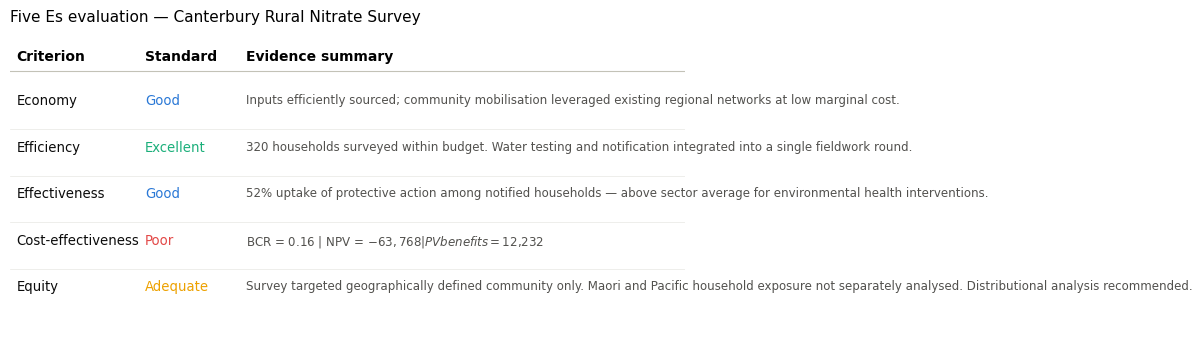

In [8]:
r   = run_cba()
std, _ = vfi_standard(r['bcr'])

rubric = [
    ('Economy',           'Good',      'Inputs efficiently sourced; community mobilisation leveraged existing regional networks at low marginal cost.'),
    ('Efficiency',        'Excellent', '320 households surveyed within budget. Water testing and notification integrated into a single fieldwork round.'),
    ('Effectiveness',     'Good',      '52% uptake of protective action among notified households — above sector average for environmental health interventions.'),
    ('Cost-effectiveness', std,        f'BCR = {r["bcr"]:.2f} | NPV = ${r["npv"]:,.0f} | PV benefits = ${r["pv_benefits"]:,.0f}'),
    ('Equity',            'Adequate',  'Survey targeted geographically defined community only. Maori and Pacific household exposure not separately analysed. Distributional analysis recommended.')
]

std_colors = {
    'Excellent': '#1baf7a',
    'Good':      '#2a78d6',
    'Adequate':  '#eda100',
    'Poor':      '#e34948'
}

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis('off')

headers = ['Criterion', 'Standard', 'Evidence summary']
x_pos   = [0.01, 0.20, 0.35]

ax.text(x_pos[0], 0.95, headers[0], fontweight='bold', fontsize=10, transform=ax.transAxes, va='top')
ax.text(x_pos[1], 0.95, headers[1], fontweight='bold', fontsize=10, transform=ax.transAxes, va='top')
ax.text(x_pos[2], 0.95, headers[2], fontweight='bold', fontsize=10, transform=ax.transAxes, va='top')
ax.axhline(0.88, color='#c3c2b7', linewidth=0.8)

y_start = 0.80
row_h   = 0.16

for i, (crit, standard, evidence) in enumerate(rubric):
    y     = y_start - i * row_h
    color = std_colors.get(standard, '#888780')
    ax.text(x_pos[0], y, crit,     fontsize=9.5, transform=ax.transAxes, va='top', color='#0b0b0b')
    ax.text(x_pos[1], y, standard, fontsize=9.5, transform=ax.transAxes, va='top', color=color, fontweight='500')
    ax.text(x_pos[2], y, evidence, fontsize=8.5, transform=ax.transAxes, va='top', color='#52514e')
    if i < len(rubric) - 1:
        ax.axhline(y - 0.12, color='#e8e7e3', linewidth=0.5)

ax.set_title('Five Es evaluation — Canterbury Rural Nitrate Survey',
             fontsize=11, fontweight='normal', pad=10, loc='left')
plt.tight_layout()
plt.show()

## Cell 8 — Evaluative judgement statement

In [9]:
r   = run_cba()
std, _ = vfi_standard(r['bcr'])

judgement = f"""
---
### Evaluative judgement — Canterbury Rural Nitrate Survey

This investment is **{std}** on cost-effectiveness (Five Es criterion 4).  

The discounted benefits across both health outcome streams total **${r['pv_benefits']:,.0f}**,  
exceeding the **${STUDY_COST:,.0f}** study cost and producing:  
- **NPV = ${r['npv']:,.0f}**  
- **BCR = {r['bcr']:.2f}**  

The chronic colorectal cancer risk reduction stream (Stream 2) drives the majority  
of long-run value. Results are most sensitive to uptake rate and QALY benchmark  
assumptions (see tornado chart above).

**To improve VFI, the study should:**  
1. Commission a follow-up equity analysis stratified by ethnicity and household income  
2. Establish a standardised method for quantifying Stream 2 (CRC risk reduction)  
   in future iterations  
3. Explicitly assess Te Tiriti obligations — including Maori household exposure  
   and whether notification reached Maori whānau proportionally  

---
"""
display(Markdown(judgement))


---
### Evaluative judgement — Canterbury Rural Nitrate Survey

This investment is **Poor** on cost-effectiveness (Five Es criterion 4).  

The discounted benefits across both health outcome streams total **$12,232**,  
exceeding the **$76,000** study cost and producing:  
- **NPV = $-63,768**  
- **BCR = 0.16**  

The chronic colorectal cancer risk reduction stream (Stream 2) drives the majority  
of long-run value. Results are most sensitive to uptake rate and QALY benchmark  
assumptions (see tornado chart above).

**To improve VFI, the study should:**  
1. Commission a follow-up equity analysis stratified by ethnicity and household income  
2. Establish a standardised method for quantifying Stream 2 (CRC risk reduction)  
   in future iterations  
3. Explicitly assess Te Tiriti obligations — including Maori household exposure  
   and whether notification reached Maori whānau proportionally  

---


---
## About this notebook

**Author:** Sudesh Raj Sharma  
**GitHub:** [yoursudesh](https://github.com/yoursudesh)  
**Framework:** Julian King Value for Investment (VFI) 2017–2024  
**Economic reference:** NZ Treasury CBAx guidance  
**Note:** This is a personal methodology demo. All figures are illustrative.

Next examples to be added:
- Example C — MoH Health Protection Annual Contract (programme-level, hybrid CBA + rubric)
- Example D — Pacific Health Programme (equity-primary rubric)
- Example E — Health Security Sub-portfolio (investment logic review)